# Actuarial Experience Study
## Step 1: Data Exploration

# Canada Mortality Table Analysis

This notebook processes and explores a Canadian life table dataset.  
The goal is to transform the raw actuarial life table into a clean dataset that can be used for mortality modeling and insurance risk analysis.

## Objectives

1. Extract male and female mortality tables from the raw Excel dataset
2. Clean and standardize actuarial variables
3. Create a unified mortality dataset
4. Perform exploratory analysis of mortality patterns

## Key Variables

| Variable | Description |
|--------|-------------|
age | Age in years |
survivors_lx | Number of individuals surviving to age x |
deaths_dx | Number of deaths between age x and x+1 |
mortality_rate_qx | Probability of death between age x and x+1 |
survival_probability_px | Probability of surviving one additional year |
life_expectancy_ex | Expected remaining lifetime at age x |

## Exploratory Analysis

The notebook visualizes:

- Mortality rate by age
- Life expectancy trends
- Survivorship curves

These analyses help illustrate fundamental mortality patterns used in actuarial science and insurance pricing.

In [80]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
#Load Dataset

life_raw = pd.read_excel(
    "../data/raw/canada_life_table.xlsx",
    sheet_name="2019",
    header=None
)
life_raw.iloc[15:40]

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,NaN,Complete life table / Table complète de mortalité,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Complete life table / Table complète de mortalité,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,Canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Canada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,NaN,Males / Hommes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Both sexes / Deux sexes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,Age / Âge,lx,dx,qx,m.e.(qx),px,Lx,Tx,ex,...,Age / Âge,lx,dx,qx,m.e.(qx),px,Lx,Tx,ex,m.e.(ex)
21,NaN,NaN,number / nombre,NaN,probability / probabilité,NaN,NaN,number / nombre,NaN,year / année,...,NaN,number / nombre,NaN,probability / probabilité,NaN,NaN,number / nombre,NaN,year / année,NaN
22,NaN,0 year / 0 an,100000,489,0.00489,0.00031,0.99511,99551,8010812,80.11,...,0 year / 0 an,100000,439,0.00439,0.00021,0.99561,99599,8222807,82.23,0.05
23,NaN,1 year / 1 an,99511,26,0.00026,0.00007,0.99974,99500,7911262,79.5,...,1 year / 1 an,99561,24,0.00024,0.00005,0.99976,99549,8123208,81.59,0.04
24,NaN,2 years / 2 ans,99485,18,0.00019,0.00006,0.99981,99473,7811762,78.52,...,2 years / 2 ans,99537,17,0.00017,0.00004,0.99983,99527,8023659,80.61,0.04


In [82]:
male_table = life_raw.iloc[21:133, 1:11].copy()
male_table.columns = [
    "age",
    "lx",
    "dx",
    "qx",
    "mx",
    "px",
    "Lx",
    "Tx",
    "ex",
    "mex"
]
male_table["sex"] = "male"
male_table

,age,lx,dx,qx,mx,px,Lx,Tx,ex,mex,sex
21,NaN,number / nombre,NaN,probability / probabilité,NaN,NaN,number / nombre,NaN,year / année,NaN,male
22,0 year / 0 an,100000,489,0.00489,0.00031,0.99511,99551,8010812,80.11,0.07,male
23,1 year / 1 an,99511,26,0.00026,0.00007,0.99974,99500,7911262,79.5,0.06,male
24,2 years / 2 ans,99485,18,0.00019,0.00006,0.99981,99473,7811762,78.52,0.06,male
25,3 years / 3 ans,99467,14,0.00014,0.00005,0.99986,99459,7712289,77.54,0.06,male
...,...,...,...,...,...,...,...,...,...,...,...
128,106 years / 106 ans,78,37,0.4784,0.1902,0.5216,59,118,1.52,0.52,male
129,107 years / 107 ans,40,20,0.49633,0.24409,0.50367,30,59,1.46,0.68,male
130,108 years / 108 ans,20,10,0.51311,0.49621,0.48689,15,29,1.41,0.99,male
131,109 years / 109 ans,10,5,0.52869,0.40217,0.47131,7,14,1.37,0.74,male


In [83]:
female_table = life_raw.iloc[21:133, 12:22].copy()
female_table.columns = [
    "age",
    "lx",
    "dx",
    "qx",
    "mx",
    "px",
    "Lx",
    "Tx",
    "ex",
    "mex"
]
female_table["sex"] = "female"
female_table

,age,lx,dx,qx,mx,px,Lx,Tx,ex,mex,sex
21,NaN,number / nombre,NaN,probability / probabilité,NaN,NaN,number / nombre,NaN,year / année,NaN,female
22,0 year / 0 an,100000,387,0.00387,0.00029,0.99613,99650,8432197,84.32,0.06,female
23,1 year / 1 an,99613,22,0.00022,0.00007,0.99978,99601,8332547,83.65,0.06,female
24,2 years / 2 ans,99591,16,0.00016,0.00006,0.99984,99583,8232946,82.67,0.06,female
25,3 years / 3 ans,99575,13,0.00013,0.00005,0.99987,99571,8133363,81.68,0.06,female
...,...,...,...,...,...,...,...,...,...,...,...
128,106 years / 106 ans,323,142,0.44149,0.07276,0.55851,251,537,1.66,0.24,female
129,107 years / 107 ans,180,83,0.46227,0.11899,0.53773,139,286,1.59,0.33,female
130,108 years / 108 ans,97,47,0.48193,0.18138,0.51807,74,147,1.52,0.41,female
131,109 years / 109 ans,50,25,0.50038,0.20944,0.49962,38,74,1.47,0.4,female


In [89]:
mortality_table = pd.concat([male_table, female_table])
mortality_table = mortality_table.reset_index(drop=True)
mortality_table = mortality_table.drop(index=0, axis=0)
mortality_table

,age,lx,dx,qx,mx,px,Lx,Tx,ex,mex,sex
1,0 year / 0 an,100000,489,0.00489,0.00031,0.99511,99551,8010812,80.11,0.07,male
2,1 year / 1 an,99511,26,0.00026,0.00007,0.99974,99500,7911262,79.5,0.06,male
3,2 years / 2 ans,99485,18,0.00019,0.00006,0.99981,99473,7811762,78.52,0.06,male
4,3 years / 3 ans,99467,14,0.00014,0.00005,0.99986,99459,7712289,77.54,0.06,male
5,4 years / 4 ans,99453,11,0.00011,0.00005,0.99989,99446,7612829,76.55,0.06,male
...,...,...,...,...,...,...,...,...,...,...,...
219,106 years / 106 ans,323,142,0.44149,0.07276,0.55851,251,537,1.66,0.24,female
220,107 years / 107 ans,180,83,0.46227,0.11899,0.53773,139,286,1.59,0.33,female
221,108 years / 108 ans,97,47,0.48193,0.18138,0.51807,74,147,1.52,0.41,female
222,109 years / 109 ans,50,25,0.50038,0.20944,0.49962,38,74,1.47,0.4,female


In [90]:
mortality_table["age"] = (
    mortality_table["age"]
    .astype(str)
    .str.extract(r"(\d+)")
)

mortality_table = mortality_table.dropna(subset=["age"])
mortality_table.loc[:, "age"] = mortality_table["age"].astype(int)

In [91]:
mortality_table = mortality_table.rename(columns={
    "lx": "survivors_lx",
    "dx": "deaths_dx",
    "qx": "mortality_rate_qx",
    "mx": "central_death_rate_mx",
    "px": "survival_probability_px",
    "Lx": "person_years_lived_Lx",
    "Tx": "total_future_years_Tx",
    "ex": "life_expectancy_ex",
    "mex": "std_error_life_expectancy"
})
mortality_table

,age,survivors_lx,deaths_dx,mortality_rate_qx,central_death_rate_mx,survival_probability_px,person_years_lived_Lx,total_future_years_Tx,life_expectancy_ex,std_error_life_expectancy,sex
1,0,100000,489,0.00489,0.00031,0.99511,99551,8010812,80.11,0.07,male
2,1,99511,26,0.00026,0.00007,0.99974,99500,7911262,79.5,0.06,male
3,2,99485,18,0.00019,0.00006,0.99981,99473,7811762,78.52,0.06,male
4,3,99467,14,0.00014,0.00005,0.99986,99459,7712289,77.54,0.06,male
5,4,99453,11,0.00011,0.00005,0.99989,99446,7612829,76.55,0.06,male
...,...,...,...,...,...,...,...,...,...,...,...
219,106,323,142,0.44149,0.07276,0.55851,251,537,1.66,0.24,female
220,107,180,83,0.46227,0.11899,0.53773,139,286,1.59,0.33,female
221,108,97,47,0.48193,0.18138,0.51807,74,147,1.52,0.41,female
222,109,50,25,0.50038,0.20944,0.49962,38,74,1.47,0.4,female


In [92]:
mortality_table.to_csv(
    "../data/processed/mortality_table.csv",
    index=False
)

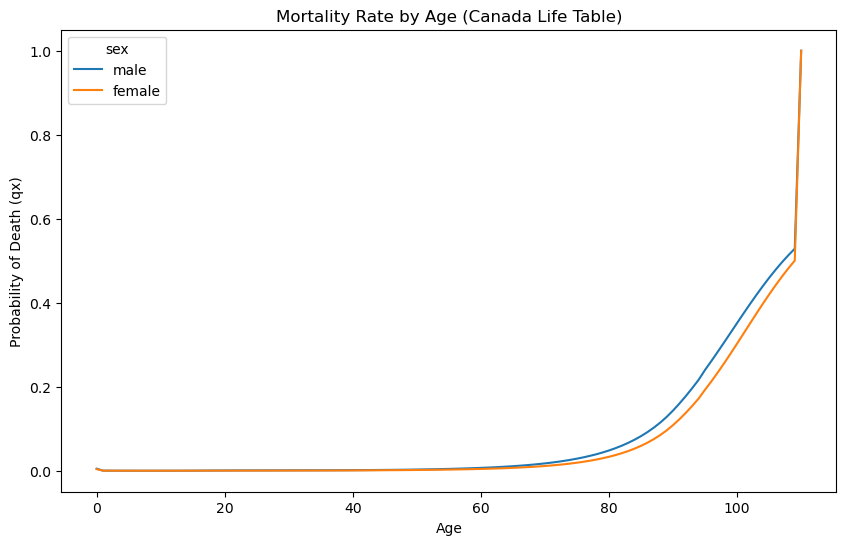

In [93]:
#Mortality Curve
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=mortality_table,
    x="age",
    y="mortality_rate_qx",
    hue="sex"
)

plt.title("Mortality Rate by Age (Canada Life Table)")
plt.xlabel("Age")
plt.ylabel("Probability of Death (qx)")
plt.show()

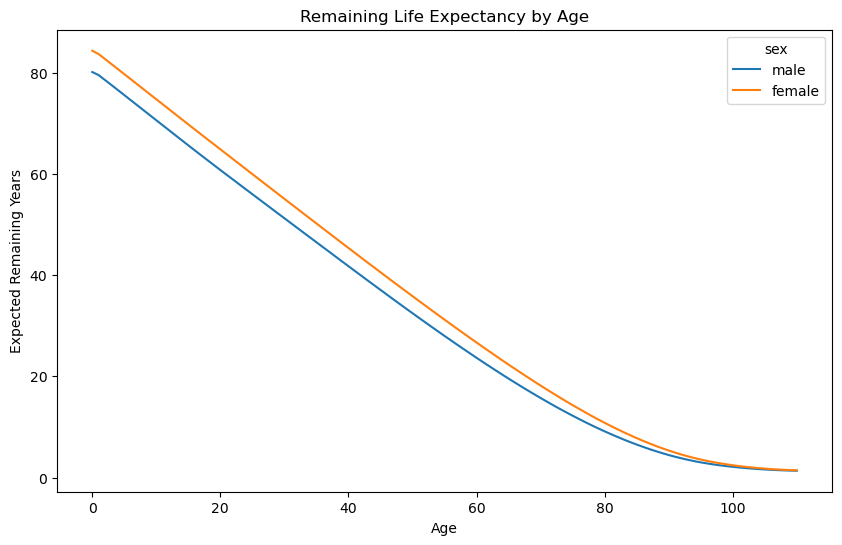

In [94]:
#Life Expectancy
plt.figure(figsize=(10,6))

sns.lineplot(
    data=mortality_table,
    x="age",
    y="life_expectancy_ex",
    hue="sex"
)

plt.title("Remaining Life Expectancy by Age")
plt.xlabel("Age")
plt.ylabel("Expected Remaining Years")
plt.show()

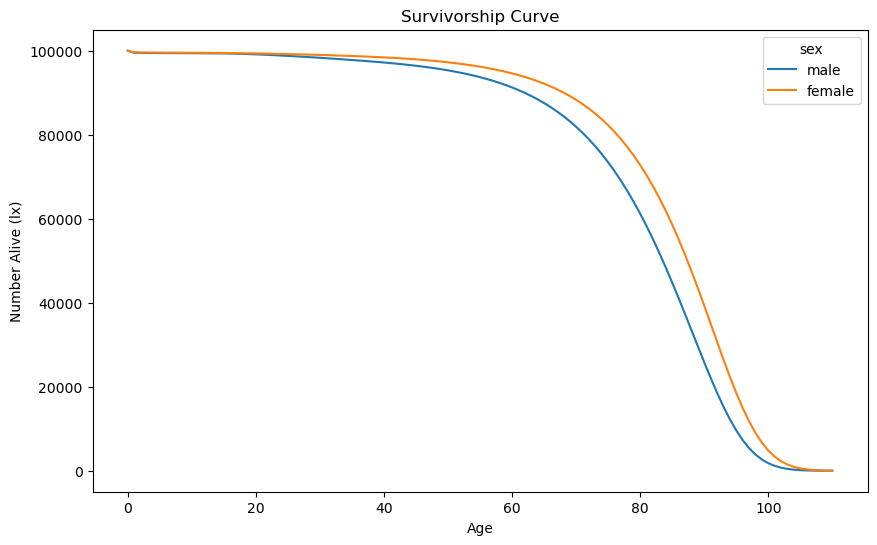

In [95]:
#Surviorship curve
plt.figure(figsize=(10,6))

sns.lineplot(
    data=mortality_table,
    x="age",
    y="survivors_lx",
    hue="sex"
)

plt.title("Survivorship Curve")
plt.xlabel("Age")
plt.ylabel("Number Alive (lx)")
plt.show()